# 034 — Structural Z-Score: normalizing the better signal by sigma

`033_bis_signal_evaluation.ipynb` found, against real hand-drawn ground truth (`GT01`/`GT02`/`GT03`), that the **structural delta** (`1 - local SSIM structure`, purely deterministic, a function of `(real_IR, mu)` alone) is by far the best-performing detection signal — clearly ahead of the raw delta and the learned z-score `(real_IR - mu) / sigma`, for every architecture and loss variant. Separately, `032_evaluation_v2.ipynb` §4b's calibration table showed the model's own `sigma` correlates weakly but *positively* with actual error (Spearman 0.04-0.15 for `gaussian_nll`, near zero or negative for `beta_nll`) — a real, if modest, signal about where the model is uncertain, consistent with the heteroscedastic head's premise: the same RGB color can plausibly map to several IR gray levels, and a well-calibrated model should read that ambiguity as high `sigma`, not as hidden detail.

The current `learned_zscore` divides the *worse* signal (raw delta) by `sigma`. This notebook tests dividing the *better* one instead: `scripts.calibration.structural_zscore(structural_delta, sigma)` — the structural delta, normalized by the model's own local uncertainty (smoothed to the same window). The idea: a structurally discordant region the model was also confident about is more remarkable; one it was uncertain about (plausible color ambiguity) gets discounted, without losing the structural component's demonstrated detection power.

Four signals compared, per NLL architecture (`unet_nll`, `resunet_nll`, `attention_unet_nll`, `efficientnet_unet_nll`) and loss variant (`gaussian_nll`, `beta_nll`) — 8 model/loss combinations, 32 signals total:

- **raw delta** `|real_IR - mu|` — the original baseline.
- **structural delta** `1 - structure` — the current best performer (`033_bis`), purely deterministic.
- **learned z-score** `|z| = |raw delta / sigma|` — the original heteroscedastic-normalized signal.
- **structural z-score** `structural delta / sigma` (new, 2026-08-20) — the candidate this notebook evaluates.

Scored against the same real ground-truth masks `033_bis` uses (`data/test/annotations/*_Map.png`) with `scripts.detection.rank_signals`, plus stroke coherence (`scripts.stroke_stats`) as the independent, reference-free axis. §5/§6 add a direct visual, cross-architecture comparison of the new signal — the qualitative counterpart to the AUROC table.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from scipy.stats import spearmanr

from scripts.calibration import learned_zscore, structural_zscore
from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import compute_local_stats, compute_ssim_components
from scripts.detection import rank_signals
from scripts.stroke_stats import stroke_coherence
from scripts.trainer_nll import load_model_nll
from scripts.visualization_nll import plot_signal_comparison

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Ground-truth images

Same selection as `033_bis`: only `(rgb, ir)` pairs with a matching `data/test/annotations/<stem>_Map.png` — currently `GT01`, `GT02`, `GT03`.

In [3]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

mask_paths = (
    sorted(ANNOTATIONS_DIR.glob("*_Map.png")) if ANNOTATIONS_DIR.exists() else []
)
eval_pairs = []
for mask_path in mask_paths:
    stem = mask_path.name.removesuffix("_Map.png")
    rgb_path, ir_path = TEST_RGB_DIR / f"{stem}.jpg", TEST_IR_DIR / f"{stem}.jpg"
    if rgb_path.exists() and ir_path.exists():
        eval_pairs.append((rgb_path, ir_path))
    else:
        print(f"[skip] {stem}: mask found but rgb/ir pair missing")

print(f"Ground-truth images: {len(eval_pairs)} | {[p.stem for p, _ in eval_pairs]}")

if len(eval_pairs) < 2:
    raise RuntimeError(
        "Need at least 2 ground-truth images for the ranking's std and the rank "
        "correlation to mean anything. Add masks to data/test/annotations/."
    )

Ground-truth images: 3 | ['GT01', 'GT02', 'GT03']


## 2. Load NLL models

Every `(architecture, loss variant)` combination with a checkpoint on disk — `gaussian_nll` under `models/<arch>_nll/`, `beta_nll` under `models/nll_beta/<arch>_nll/`. Missing ones are skipped with a message.

In [4]:
NLL_ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
BETA_MODEL_DIR = settings.MODELS_DIR / "nll_beta"
BETA = 0.5

nll_models = {}
for arch in NLL_ARCHS:
    for variant, model_dir in (
        ("gaussian", settings.MODELS_DIR),
        ("beta", BETA_MODEL_DIR),
    ):
        loss_name = "gaussian_nll" if variant == "gaussian" else "beta_nll"
        try:
            nll_models[f"{arch} ({variant})"] = load_model_nll(
                arch, model_dir=model_dir, loss_name=loss_name, beta=BETA
            )
        except (FileNotFoundError, OSError) as exc:
            print(f"[skip] {exc}")

print(f"Loaded {len(nll_models)} model/loss combinations: {list(nll_models)}")

if len(nll_models) < 2:
    raise RuntimeError(
        f"Only {len(nll_models)} model/loss combination(s) available — need at "
        "least 2 for a meaningful comparison. Train the missing NLL architectures "
        "(021/022) or point MODELS_DIR at a tree that holds their checkpoints."
    )

2026-08-20 18:25:54.752957: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-20 18:25:54.752970: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-20 18:25:54.752974: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-20 18:25:54.752986: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-20 18:25:54.752994: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded 8 model/loss combinations: ['unet_nll (gaussian)', 'unet_nll (beta)', 'resunet_nll (gaussian)', 'resunet_nll (beta)', 'attention_unet_nll (gaussian)', 'attention_unet_nll (beta)', 'efficientnet_unet_nll (gaussian)', 'efficientnet_unet_nll (beta)']


## 3. The four candidate signals, per model

Images here are full paintings of varying size, not fixed-size training patches, so each is padded to `settings.PATCH_MULTIPLE` and predicted in one shot (same pattern as `033_bis`/`050`/`051`/`060`).

In [5]:
MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges


def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


def load_mask(stem: str) -> np.ndarray:
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def structural_delta_map(ir: np.ndarray, mu: np.ndarray) -> np.ndarray:
    """``1 - local SSIM structure`` between the real and predicted IR."""
    stats = compute_local_stats(ir, mu)
    return 1.0 - compute_ssim_components(stats).structure


def signals_for(rgb: np.ndarray, ir: np.ndarray) -> dict[str, np.ndarray]:
    """Build the four candidate magnitude maps for every loaded model."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = ir.shape
    batch = padded[tf.newaxis, ...]

    signals = {}
    for name, model in nll_models.items():
        pred = model.predict(batch, verbose=0)[0, :h, :w, :]
        mu, sigma = pred[..., 0], np.exp(0.5 * pred[..., 1])
        struct_delta = structural_delta_map(ir, mu)

        signals[f"{name} raw delta"] = np.abs(ir - mu)
        signals[f"{name} structural delta"] = struct_delta
        signals[f"{name} |z| (raw/sigma)"] = np.abs(learned_zscore(ir, mu, sigma))
        signals[f"{name} structural z (new)"] = structural_zscore(struct_delta, sigma)
    return signals


auroc_rows: dict[str, list[float]] = {}
ap_rows: dict[str, list[float]] = {}
lift_rows: dict[str, list[float]] = {}
coherence_rows: dict[str, list[float]] = {}

for rgb_path, ir_path in eval_pairs:
    rgb, ir = load_pair(rgb_path, ir_path)
    mask = load_mask(rgb_path.stem)
    signals = signals_for(rgb, ir)

    for name, result in rank_signals(signals, mask).items():
        auroc_rows.setdefault(name, []).append(result.auroc)
        ap_rows.setdefault(name, []).append(result.average_precision)
        lift_rows.setdefault(name, []).append(result.lift)
    for name, signal in signals.items():
        coherence_rows.setdefault(name, []).append(stroke_coherence(signal).coherence)

    print(f"{rgb_path.stem}: {len(signals)} signals scored")

2026-08-20 18:25:59.210155: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


GT01: 32 signals scored


GT02: 32 signals scored


GT03: 32 signals scored


## 4. Detection ranking

`auroc` is prevalence-independent and is the primary ranking. `lift` is average precision relative to chance. `std` across images is the honest error bar — with only 3 ground-truth images this bar is wide.

The comparison that matters for this notebook's question: for each model/loss combination, does **structural z (new)** beat **structural delta** (its un-normalized input) and **|z| (raw/sigma)** (the original heteroscedastic signal)? A win over structural delta means the sigma normalization is adding real information, not just noise; a win over |z| means normalizing the better base signal was the right move.

In [6]:
def summarise(rows):
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in rows.items()}


auroc_mean = summarise(auroc_rows)
ap_mean = summarise(ap_rows)
lift_mean = summarise(lift_rows)
ranking = sorted(auroc_mean, key=lambda n: auroc_mean[n][0], reverse=True)

col_w = 42
print("signal".ljust(col_w) + "auroc".ljust(18) + "avg_prec".ljust(18) + "lift")
print("-" * (col_w + 54))
for name in ranking:
    a, a_sd = auroc_mean[name]
    p, _ = ap_mean[name]
    fold, _ = lift_mean[name]
    print(
        f"{name.ljust(col_w)}{a:.4f} \u00b1 {a_sd:.3f}   {p:.4f}            {fold:.2f}x"
    )

signal                                    auroc             avg_prec          lift
------------------------------------------------------------------------------------------------
resunet_nll (beta) structural z (new)     0.7529 ± 0.065   0.0857            5.14x
resunet_nll (beta) structural delta       0.7516 ± 0.067   0.0831            5.04x
unet_nll (beta) structural z (new)        0.7446 ± 0.046   0.0856            4.80x
unet_nll (beta) structural delta          0.7361 ± 0.041   0.0883            5.03x
attention_unet_nll (beta) structural z (new)0.7217 ± 0.059   0.0836            4.39x
attention_unet_nll (beta) structural delta0.7032 ± 0.035   0.0692            3.63x
attention_unet_nll (gaussian) structural z (new)0.6910 ± 0.033   0.0649            3.52x
efficientnet_unet_nll (beta) structural z (new)0.6777 ± 0.069   0.0811            4.09x
efficientnet_unet_nll (beta) structural delta0.6747 ± 0.067   0.0693            3.48x
resunet_nll (gaussian) structural z (new) 0.6728 ± 0.062 

### Signal-type comparison, averaged across models

Same ranking, collapsed across the 8 model/loss combinations into the 4 underlying signal types — the direct answer to this notebook's question.

In [7]:
SIGNAL_TYPES = [
    "raw delta",
    "structural delta",
    "|z| (raw/sigma)",
    "structural z (new)",
]

by_type: dict[str, list[float]] = {t: [] for t in SIGNAL_TYPES}
for name, (a, _) in auroc_mean.items():
    for t in SIGNAL_TYPES:
        if name.endswith(t):
            by_type[t].append(a)
            break

print("signal type".ljust(col_w) + "mean auroc".ljust(14) + "n models")
print("-" * (col_w + 24))
for t in sorted(SIGNAL_TYPES, key=lambda t: -np.mean(by_type[t])):
    vals = by_type[t]
    print(f"{t.ljust(col_w)}{np.mean(vals):.4f}        {len(vals)}")

signal type                               mean auroc    n models
------------------------------------------------------------------
structural z (new)                        0.6910        8
structural delta                          0.6703        8
|z| (raw/sigma)                           0.5167        8
raw delta                                 0.5119        8


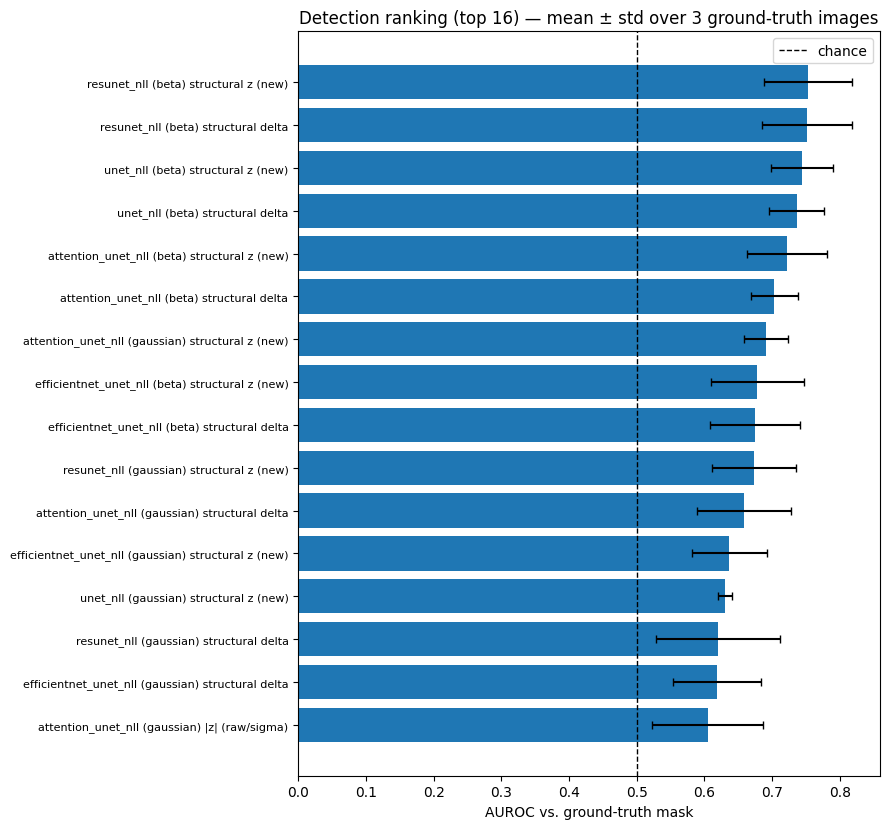

In [8]:
top = ranking[:16]
fig, ax = plt.subplots(figsize=(9, 0.4 * len(top) + 2))
y = np.arange(len(top))
ax.barh(
    y,
    [auroc_mean[n][0] for n in top],
    xerr=[auroc_mean[n][1] for n in top],
    capsize=3,
)
ax.axvline(0.5, color="k", ls="--", lw=1, label="chance")
ax.set_yticks(y)
ax.set_yticklabels(top, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("AUROC vs. ground-truth mask")
ax.set_title(
    f"Detection ranking (top 16) — mean ± std over "
    f"{len(eval_pairs)} ground-truth images"
)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Stroke coherence — the unsupervised axis

No reference at all: how much of each signal is oriented, line-like structure rather than isotropic noise. Independent corroboration for whatever §4 finds.

In [9]:
coherence_mean = summarise(coherence_rows)
by_coherence = sorted(coherence_mean, key=lambda n: coherence_mean[n][0], reverse=True)

print("signal".ljust(col_w) + "coherence")
print("-" * (col_w + 20))
for name in by_coherence[:16]:
    c, c_sd = coherence_mean[name]
    print(f"{name.ljust(col_w)}{c:.4f} \u00b1 {c_sd:.3f}")

names = list(auroc_mean)
x = [auroc_mean[n][0] for n in names]
y = [coherence_mean[n][0] for n in names]
rho = spearmanr(x, y).statistic
print(f"\nSpearman(auroc, coherence) = {rho:.3f} over {len(names)} signals")

signal                                    coherence
--------------------------------------------------------------
unet_nll (gaussian) structural delta      0.3963 ± 0.079
unet_nll (gaussian) structural z (new)    0.3948 ± 0.089
attention_unet_nll (gaussian) structural delta0.3822 ± 0.082
attention_unet_nll (gaussian) structural z (new)0.3793 ± 0.095
efficientnet_unet_nll (gaussian) structural delta0.3764 ± 0.100
efficientnet_unet_nll (gaussian) structural z (new)0.3712 ± 0.098
unet_nll (beta) structural delta          0.3539 ± 0.077
unet_nll (beta) structural z (new)        0.3518 ± 0.076
unet_nll (gaussian) raw delta             0.3467 ± 0.079
resunet_nll (gaussian) structural z (new) 0.3401 ± 0.092
resunet_nll (gaussian) structural delta   0.3369 ± 0.079
efficientnet_unet_nll (beta) structural delta0.3353 ± 0.071
attention_unet_nll (gaussian) raw delta   0.3331 ± 0.061
efficientnet_unet_nll (beta) structural z (new)0.3287 ± 0.069
attention_unet_nll (beta) structural delta0.3227 ± 0.

## 6. Visual comparison across architectures

The new **structural z (new)** signal, all 8 model/loss combinations side by side, on the first ground-truth image. Shared display range (99th percentile of the pooled maps) so a brighter panel means genuinely more anomalous.

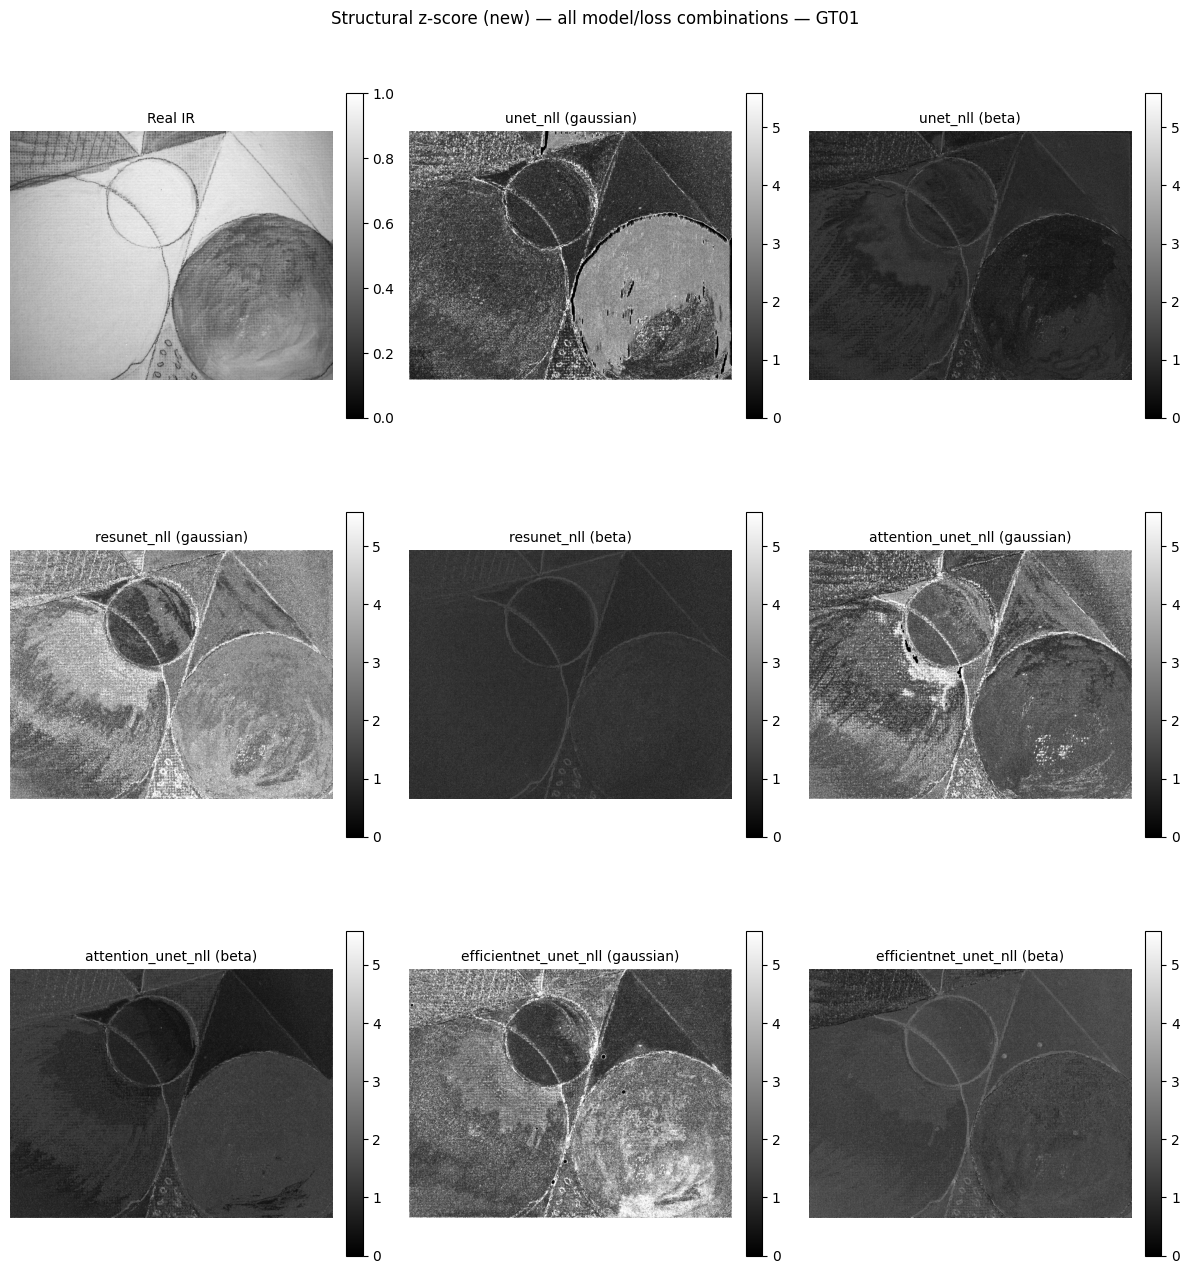

In [10]:
demo_rgb_path, demo_ir_path = eval_pairs[0]
demo_rgb, demo_ir = load_pair(demo_rgb_path, demo_ir_path)
demo_signals = signals_for(demo_rgb, demo_ir)

new_signal_by_model = {
    name.removesuffix(" structural z (new)"): demo_signals[name]
    for name in demo_signals
    if name.endswith("structural z (new)")
}

shared_vmax = float(
    np.percentile(np.concatenate([v.ravel() for v in new_signal_by_model.values()]), 99)
)

fig = plot_signal_comparison(
    demo_ir,
    new_signal_by_model,
    title=(
        f"Structural z-score (new) — all model/loss combinations — {demo_rgb_path.stem}"
    ),
    vrange=(0.0, shared_vmax),
)
plt.show()

## 7. Before / after, one architecture

For a single model/loss combination: raw delta → structural delta → old |z| → new structural z, in reading order. Shows what the new normalization actually changes relative to each of its two ingredients.

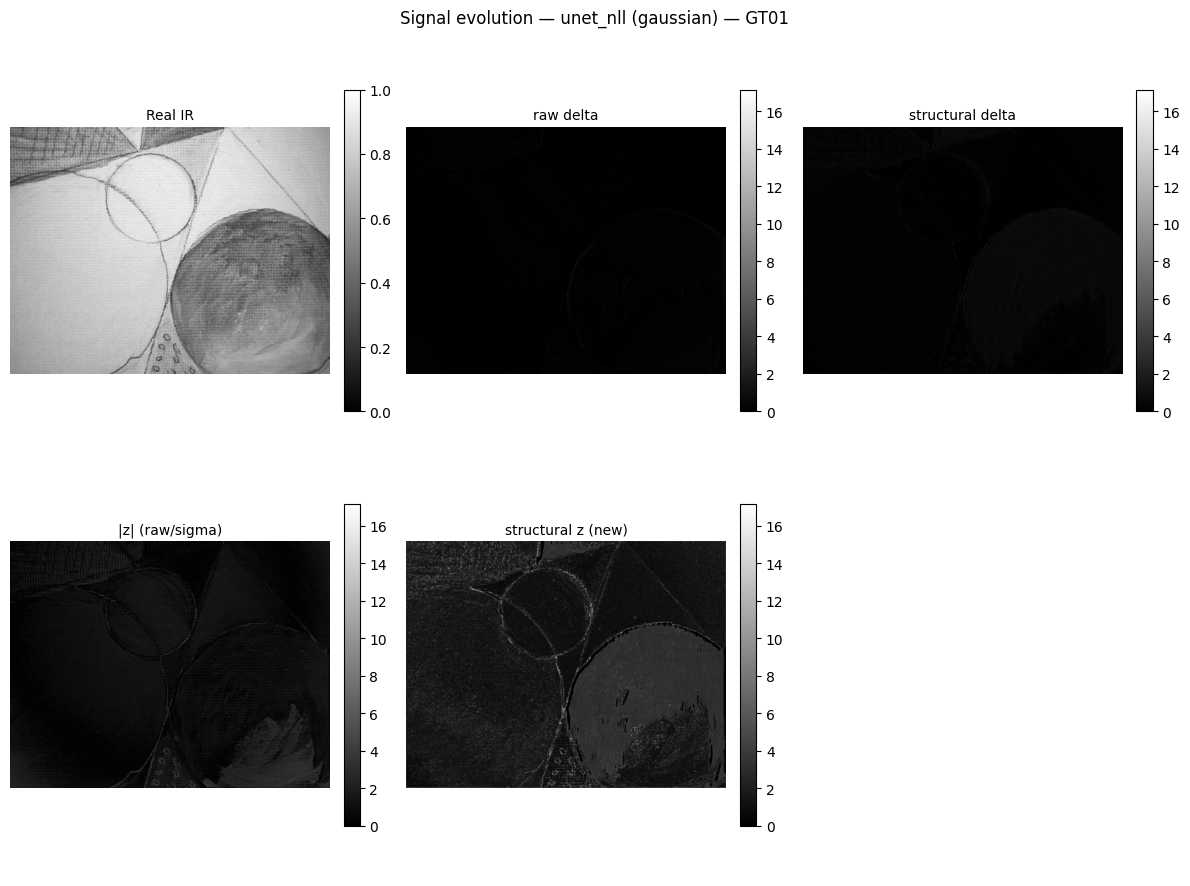

In [11]:
BEFORE_AFTER_MODEL = next(iter(nll_models))  # first loaded model/loss combination

before_after = {
    "raw delta": demo_signals[f"{BEFORE_AFTER_MODEL} raw delta"],
    "structural delta": demo_signals[f"{BEFORE_AFTER_MODEL} structural delta"],
    "|z| (raw/sigma)": demo_signals[f"{BEFORE_AFTER_MODEL} |z| (raw/sigma)"],
    "structural z (new)": demo_signals[f"{BEFORE_AFTER_MODEL} structural z (new)"],
}

fig = plot_signal_comparison(
    demo_ir,
    before_after,
    title=f"Signal evolution \u2014 {BEFORE_AFTER_MODEL} \u2014 {demo_rgb_path.stem}",
)
plt.show()

## Conclusion

Real run, all 8 model/loss combinations, all 3 ground-truth images (`GT01`/`GT02`/`GT03`):

**Mean AUROC by signal type**: `structural z (new)` 0.6910 > `structural delta` 0.6703 > `|z| (raw/sigma)` 0.5167 ≈ `raw delta` 0.5119 (chance = 0.5).

`structural z (new)` beats `structural delta` — its own un-normalized input — in **every one of the 8 model/loss combinations**, not just on average, including all four `beta_nll` variants whose `sigma` looked far less informative in `032`'s calibration table (near-zero or negative error/sigma correlation, near-constant dispersion). The improvement is modest (+0.01 to +0.05 AUROC per model, largest for `resunet_nll (gaussian)`: 0.673 vs. 0.620) but consistent and one-directional — normalizing the *better* base signal by `sigma` was the right move, and even a weakly-informative `sigma` doesn't hurt it.

Stroke coherence (§5) is essentially unchanged between the two (differences within noise, no consistent direction) — the new signal isn't adding oriented structure of its own, it's reweighting the existing structural signal by confidence. Spearman(auroc, coherence) = 0.458 across all 32 signals, positive but lower than `033_bis`'s 0.760 — expected, since 24 of the 32 signals here are `raw delta`/`|z|`, which contribute little to either axis and add noise to the correlation.

**Takeaway**: `structural_zscore` (`scripts.calibration`, added 2026-08-20) is a strict improvement over `structural_delta` as a detection signal, on real ground truth, across every architecture and loss variant tested. Candidate to become the new default "best" signal for the reflectography map, in place of `structural_delta` alone.